In [2]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
import matplotlib.pyplot as plt
%matplotlib inline

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.utils.visualizer import ColorMode
from detectron2.structures import Instances

from train_is import configure_dataset
from btn_label_assoc import BTNLabelAssoc
from generate_pairs import get_nearest_k_btns

/home/abhinavchadaga/cs/fri_II/final_project/.venv/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path_to_dataset = "datasets/elevator_panels"
configure_dataset(path_to_dataset=path_to_dataset)

In [4]:
cascade_mask_rcnn_config = "Misc/cascade_mask_rcnn_R_50_FPN_3x.yaml"
mask_rcnn_config = "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(cascade_mask_rcnn_config))
cfg.DATASETS.TRAIN = ("elevators", )
cfg.DATASETS.TEST = ()
cfg.MODEL.WEIGHTS = "/home/abhinavchadaga/cs/fri_II/final_project/trained_weights/model_final.pth"
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

[12/08 06:15:09 d2.checkpoint.c2_model_loading]: Following weights matched with model:
| Names in Model                                  | Names in Checkpoint                                                                                  | Shapes                                          |
|:------------------------------------------------|:-----------------------------------------------------------------------------------------------------|:------------------------------------------------|
| backbone.bottom_up.res2.0.conv1.*               | backbone.bottom_up.res2.0.conv1.{norm.bias,norm.running_mean,norm.running_var,norm.weight,weight}    | (64,) (64,) (64,) (64,) (64,64,1,1)             |
| backbone.bottom_up.res2.0.conv2.*               | backbone.bottom_up.res2.0.conv2.{norm.bias,norm.running_mean,norm.running_var,norm.weight,weight}    | (64,) (64,) (64,) (64,) (64,64,3,3)             |
| backbone.bottom_up.res2.0.conv3.*               | backbone.bottom_up.res2.0.conv3.{norm.bia

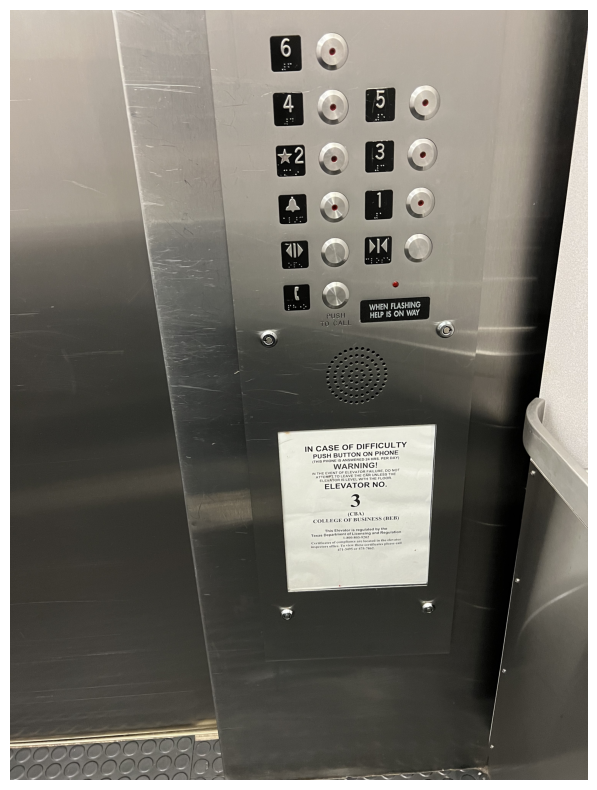

/home/abhinavchadaga/cs/fri_II/final_project/.venv/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [5]:
predictor = DefaultPredictor(cfg)
im = cv2.imread("/home/abhinavchadaga/cs/fri_II/final_project/data/panels/test/mccombs/JPEG image 3.jpeg")
plt.figure(figsize = (10, 10))
plt.imshow(im[:, :, ::-1])
plt.axis("off")
plt.show()
outputs = predictor(im)

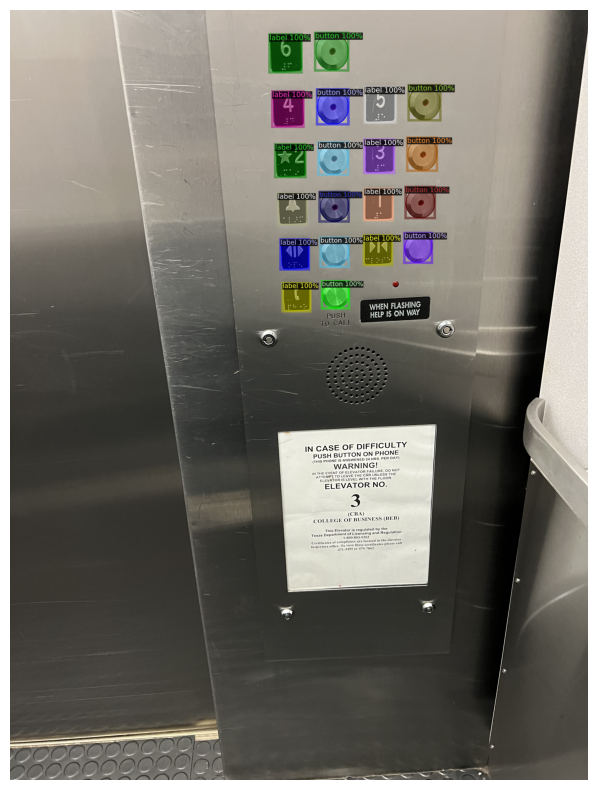

In [6]:
v = Visualizer(im[:,:,::-1], MetadataCatalog.get("elevators"), scale=1, instance_mode=ColorMode.SEGMENTATION)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2.imwrite("output.jpg", out.get_image()[:, :, ::-1])
plt.figure(figsize = (10, 10))
plt.imshow(out.get_image())
plt.axis("off")
plt.show()


In [9]:
# load checkpoint
checkpoint = "/home/abhinavchadaga/cs/fri_II/final_project/lightning_logs/version_3/checkpoints/epoch=39-step=1079.ckpt"
association_model = BTNLabelAssoc.load_from_checkpoint(checkpoint).model


FileNotFoundError: [Errno 2] No such file or directory: '/home/abhinavchadaga/cs/fri_II/final_project/lightning_logs/version_3/checkpoints/epoch=39-step=1079.ckpt'

In [ ]:
pred_boxes = [box.detach().cpu().numpy() for box in outputs["instances"].pred_boxes]
classes = [c.item() for c in outputs["instances"].pred_classes]
btn_centers = []
label_centers = []
for c, bbox in zip(classes, pred_boxes):
    center = (bbox[0] + bbox[2]) / 2, (bbox[1] + bbox[3]) / 2
    if c in (0, 2):
        btn_centers.append(center)
    elif c == 1:
        label_centers.append(center)

In [ ]:
import torch

label = label_centers[13]
nearest_btns = get_nearest_k_btns(label=label, btn_centers=btn_centers)
input_vec = []
for btn in nearest_btns:
    input_vec.extend(btn)
input_vec.extend(label)
input_vec = torch.tensor(input_vec, dtype=torch.float32).unsqueeze(0)
print(input_vec.shape)

In [ ]:
association_model.eval()
output = torch.exp(association_model(input_vec))
button = torch.argmax(output).item()
button = nearest_btns[0]

In [ ]:
plt.figure(figsize = (10, 10))
plt.imshow(im[:, :, ::-1])
plt.axis("off")
plt.plot(*label, "o", color="green")
plt.plot(*button, "o", color="red", markersize=4)

# plt.plot(*label_centers[0], "o", color="green")
# for i, p in enumerate(nearest_btns):
#     color = "green" if i == 0 else "yellow"
#     plt.plot(*p, "o", color=color, markersize=4)

